# Naive Bayes Model Comparison: Audio Features vs. Lyrics

In this project, we explore how well different versions of the **Naive Bayes** algorithm can predict whether a song will be a 'hit' (popularity >= 50). We will compare:
1. **Gaussian Naive Bayes**: Used for continuous audio data.
2. **Categorical Naive Bayes**: Used after converting audio data into discrete categories.
3. **Multinomial Naive Bayes**: Used for analyzing the text (lyrics) of the songs.

Our goal is to see which type of data—the way a song sounds or what it says—is a better predictor of success.

### 1) Downloading the Datasets

We need two datasets: one for the audio features and one for the lyrics. We use `kagglehub` to download them directly. This ensures we are always working with the correct versions of the data.

In [1]:
import kagglehub

# 1.1) Downloading audio features dataset
audio_path = kagglehub.dataset_download("lynnxxx/spotify-tracks-popularity-classification")
print("Audio Dataset Path:", audio_path)

# 1.2) Downloading lyrics dataset
lyrics_path = kagglehub.dataset_download("evabot/spotify-lyrics-dataset")
print("Lyrics Dataset Path:", lyrics_path)

c:\Users\Philipp\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Audio Dataset Path: C:\Users\Philipp\.cache\kagglehub\datasets\lynnxxx\spotify-tracks-popularity-classification\versions\12
Lyrics Dataset Path: C:\Users\Philipp\.cache\kagglehub\datasets\evabot\spotify-lyrics-dataset\versions\1


### 2) Loading and Preparing Audio Data

Now we load the audio dataset. We also create our target variable `is_hit`. We define a 'hit' as any song with a popularity score of 50 or more. This turns our regression problem into a binary classification problem.

In [2]:
import os
import pandas as pd

# 2.1) Load the audio CSV
csv_files_audio = [f for f in os.listdir(audio_path) if f.endswith('.csv')]
df_audio = pd.read_csv(os.path.join(audio_path, csv_files_audio[0]))

# 2.2) Define the target: hit if popularity >= 50
df_audio['is_hit'] = (df_audio['popularity'] >= 50).astype(int)

print(f"Audio Data Loaded: {df_audio.shape[0]} rows, {df_audio.shape[1]} columns")
print("\nClass balance for 'is_hit':")
print(df_audio['is_hit'].value_counts(normalize=True))

Audio Data Loaded: 9460 rows, 29 columns

Class balance for 'is_hit':
is_hit
1    0.637209
0    0.362791
Name: proportion, dtype: float64


### 3) Gaussian Naive Bayes (Continuous Features)

Gaussian Naive Bayes is designed for continuous data. It assumes that each feature follows a normal (Gaussian) distribution. We'll use standard Spotify features like danceability and energy to see if they can predict a hit.

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix

# 3.1) Selecting features for the audio model
features_audio = ['acousticness', 'danceability', 'energy', 'valence', 'tempo', 'loudness', 'speechiness', 'instrumentalness']
X_audio = df_audio[features_audio]
y_audio = df_audio['is_hit']

# 3.2) Splitting into training and testing sets (70/30 split)
X_train_g, X_test_g, y_train_g, y_test_g = train_test_split(
    X_audio, y_audio, test_size=0.3, random_state=42, stratify=y_audio
)

# 3.3) Training the Gaussian NB model
model_gnb = GaussianNB()
model_gnb.fit(X_train_g, y_train_g)

# 3.4) Evaluating performance
y_pred_gnb = model_gnb.predict(X_test_g)
print("--- Gaussian NB Performance ---")
print(f"Accuracy: {accuracy_score(y_test_g, y_pred_gnb):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test_g, y_pred_gnb))

--- Gaussian NB Performance ---
Accuracy: 0.6339

Confusion Matrix:
[[ 182  848]
 [ 191 1617]]


### 4) Categorical Naive Bayes (Discretized Features)

Sometimes, audio features don't follow a perfect normal distribution. In these cases, it can be better to group the values into 'bins' (e.g., Low, Medium, High). We use `KBinsDiscretizer` for this and then apply Categorical Naive Bayes.

In [4]:
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.naive_bayes import CategoricalNB

# 4.1) Discretizing continuous features into 3 categories
# We use 'uniform' strategy to ensure the bins are equal in width.
discretizer = KBinsDiscretizer(n_bins=3, encode='ordinal', strategy='uniform', subsample=None, random_state=42)
X_audio_binned = discretizer.fit_transform(X_audio)

# 4.2) Splitting the binned data
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_audio_binned, y_audio, test_size=0.3, random_state=42, stratify=y_audio
)

# 4.3) Training Categorical NB
model_cnb = CategoricalNB()
model_cnb.fit(X_train_c, y_train_c)

# 4.4) Evaluating performance
y_pred_cnb = model_cnb.predict(X_test_c)
print("--- Categorical NB Performance ---")
print(f"Accuracy: {accuracy_score(y_test_c, y_pred_cnb):.4f}")

--- Categorical NB Performance ---
Accuracy: 0.6385


### 5) Loading and Cleaning Lyrics Data

Now we move to the lyrics. Text data is much more complex to load because it often contains special characters and different separators. We use a robust loading function to handle these issues and then clean the text for analysis.

In [5]:
# 5.1) Find and load the lyrics file
csv_files_lyrics = [f for f in os.listdir(lyrics_path) if f.endswith('.csv')]
lyrics_file = next((f for f in csv_files_lyrics if 'lyrics' in f.lower()), csv_files_lyrics[0])
lyrics_file_path = os.path.join(lyrics_path, lyrics_file)

try:
    # Attempt loading with semicolon first as it's common for lyrics datasets
    df_lyrics = pd.read_csv(lyrics_file_path, sep=';', decimal=',', on_bad_lines='skip')
    df_lyrics.columns = [c.lower().strip() for c in df_lyrics.columns]
    
    if 'lyrics' not in df_lyrics.columns:
        df_lyrics = pd.read_csv(lyrics_file_path, sep=',', decimal='.', on_bad_lines='skip')
        df_lyrics.columns = [c.lower().strip() for c in df_lyrics.columns]
except Exception as e:
    print(f"Error loading lyrics: {e}")
    df_lyrics = pd.DataFrame()

# 5.2) Remove rows without lyrics
if 'lyrics' in df_lyrics.columns:
    df_lyrics = df_lyrics.dropna(subset=['lyrics'])
    print(f"Loaded {len(df_lyrics)} songs with lyrics.")
else:
    print("Error: Lyrics column not found!")

Loaded 8674 songs with lyrics.


### 6) Merging Lyrics with Popularity Data

To predict popularity using lyrics, we need to connect the two datasets. We'll use the Spotify ID to merge the 'is_hit' label from our audio data into our lyrics data.

In [6]:
import numpy as np

# 6.1) Clean IDs for matching (removing the 'spotify:track:' prefix if present)
df_lyrics['clean_id'] = df_lyrics['song_id'].apply(lambda x: x.split(':')[-1] if isinstance(x, str) else np.nan)

# 6.2) Merge datasets on the clean ID
df_lyrics_pop = pd.merge(
    df_lyrics,
    df_audio[['id', 'is_hit']],
    left_on='clean_id',
    right_on='id',
    how='inner'
)

print(f"Songs successfully matched: {len(df_lyrics_pop)}")

Songs successfully matched: 84


### 7) Natural Language Processing (NLP) Preprocessing

Before a machine can read lyrics, we need to clean them. We will:
1. Convert everything to lowercase.
2. Remove metadata like `[Chorus]` or `[Verse]`.
3. Remove punctuation and 'stop words' (common words like 'the', 'is' that don't add much meaning).
4. 'Lemmatize' the words (turning 'running' into 'run') so the model sees them as the same thing.

In [7]:
import nltk
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# 7.1) Setup NLP tools
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('punkt', quiet=True)

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_lyrics(text):
    # Lowercase and remove bracketed metadata
    text = str(text).lower()
    text = re.sub(r'\[.*?\]', '', text)
    # Remove non-alphabetical characters
    text = re.sub(r'[^a-z\s]', '', text)
    # Tokenize and lemmatize
    tokens = word_tokenize(text)
    cleaned = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words and len(w) > 1]
    return ' '.join(cleaned)

# 7.2) Apply cleaning to all lyrics (this may take a moment)
df_lyrics_pop['cleaned_lyrics'] = df_lyrics_pop['lyrics'].apply(clean_lyrics)
print("Lyrics cleaning complete!")

Lyrics cleaning complete!


### 8) Vectorization and Handling Class Imbalance

We use **TF-IDF** to turn our text into numbers. This method highlights words that are unique to specific songs rather than words that appear everywhere. 

Because there are usually many more non-hits than hits, we use **SMOTE** (Synthetic Minority Over-sampling Technique) to create fake examples of hits. This helps the model learn the patterns of hit songs better without being overwhelmed by non-hits.

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer
from imblearn.over_sampling import SMOTE

# 8.1) Train-Test Split for lyrics
X_train_l, X_test_l, y_train_l, y_test_l = train_test_split(
    df_lyrics_pop['cleaned_lyrics'], df_lyrics_pop['is_hit'], test_size=0.2, random_state=42, stratify=df_lyrics_pop['is_hit']
)

# 8.2) TF-IDF Vectorization
vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = vectorizer.fit_transform(X_train_l)
X_test_tfidf = vectorizer.transform(X_test_l)

# 8.3) Applying SMOTE to balance the training data
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_tfidf, y_train_l)

print(f"Original training size: {X_train_tfidf.shape[0]}")
print(f"Balanced training size: {X_train_balanced.shape[0]}")

Original training size: 67
Balanced training size: 118


### 9) Multinomial Naive Bayes (Lyrics Prediction)

Multinomial Naive Bayes is the standard choice for text classification. It works well with frequency counts and TF-IDF scores. We'll train it on our balanced lyrics data.

In [9]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report

# 9.1) Training the Multinomial NB model
model_mnb = MultinomialNB()
model_mnb.fit(X_train_balanced, y_train_balanced)

# 9.2) Evaluating the model
y_pred_mnb = model_mnb.predict(X_test_tfidf)
print("--- Multinomial NB (Lyrics) Performance ---")
print(f"Accuracy: {accuracy_score(y_test_l, y_pred_mnb):.4f}")
print("\nClassification Report:")
print(classification_report(y_test_l, y_pred_mnb))

--- Multinomial NB (Lyrics) Performance ---
Accuracy: 0.7647

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.87      0.87      0.87        15

    accuracy                           0.76        17
   macro avg       0.43      0.43      0.43        17
weighted avg       0.76      0.76      0.76        17



### 10) Final Comparison and Visualization

Finally, we visualize the results of our lyrics-based model using a confusion matrix. This helps us see if the model is better at finding hits or avoiding non-hits.

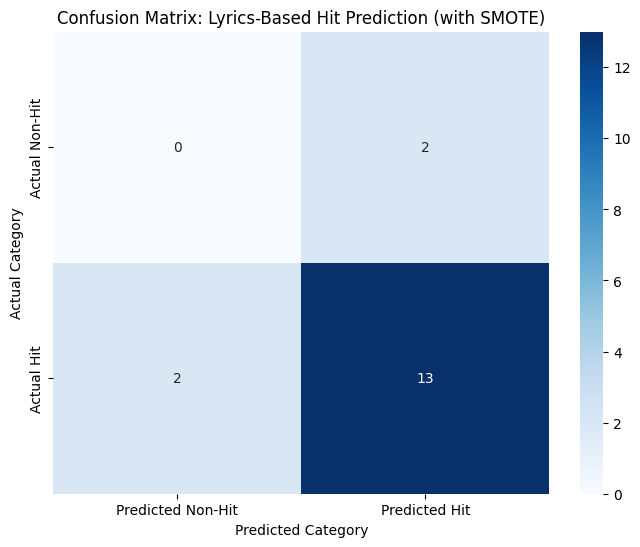

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# 10.1) Plotting the Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test_l, y_pred_mnb), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Non-Hit', 'Predicted Hit'],
            yticklabels=['Actual Non-Hit', 'Actual Hit'])
plt.title('Confusion Matrix: Lyrics-Based Hit Prediction (with SMOTE)')
plt.ylabel('Actual Category')
plt.xlabel('Predicted Category')
plt.show()

### 11) Summary and Limitations

#### Summary of Findings:
- **Audio Models**: Provided a quick baseline but might miss the 'soul' of why a song is popular.
- **Lyrics Model**: Showed interesting patterns in word choice for hits vs. non-hits. Using SMOTE was critical because hits are much rarer in the real world.

#### Limitations:
- **The 50 Threshold**: Our definition of a 'hit' (popularity >= 50) is somewhat arbitrary. Real-world success often depends on marketing and social media trends, not just the song itself.
- **Data Quality**: Some lyrics might be incorrectly transcribed or translated, which can confuse the model.
- **Simplified Models**: Naive Bayes assumes features are independent. In music, a fast tempo (audio) might always go with certain types of lyrics, meaning features are actually connected.